In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from datetime import datetime as dt

In [3]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

In [4]:
market_impact = pd.read_csv("Dados/originais/market_impact.csv")

In [5]:
market_impact.head(3)

,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.0000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.9824,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.0000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [6]:
market_impact.isnull().sum()

incident_id                          0
stock_ticker                         0
price_7d_before                      0
price_disclosure_day                 0
price_1d_after                       0
price_7d_after                       0
price_30d_after                      0
volume_avg_30d_baseline              0
volume_disclosure_day                0
sector_index                         0
sector_return_same_period            0
abnormal_return_1d                   0
abnormal_return_7d                   0
abnormal_return_30d                  0
car_neg1_to_pos1                     0
car_0_to_7                           0
car_0_to_30                          0
car_0_to_90                          0
t_statistic_1d                       0
p_value_1d                           0
t_statistic_30d                      0
p_value_30d                          0
earnings_announcement_within_7d      0
market_cap_at_disclosure             0
volume_ratio_disclosure              0
pre_incident_volatility_3

In [7]:
market_impact.info()

<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   incident_id                      358 non-null    str    
 1   stock_ticker                     358 non-null    str    
 2   price_7d_before                  358 non-null    float64
 3   price_disclosure_day             358 non-null    float64
 4   price_1d_after                   358 non-null    float64
 5   price_7d_after                   358 non-null    float64
 6   price_30d_after                  358 non-null    float64
 7   volume_avg_30d_baseline          358 non-null    int64  
 8   volume_disclosure_day            358 non-null    int64  
 9   sector_index                     358 non-null    str    
 10  sector_return_same_period        358 non-null    float64
 11  abnormal_return_1d               358 non-null    float64
 12  abnormal_return_7d               

In [8]:
market_impact.describe()

,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_return_same_period,abnormal_return_1d,abnormal_return_7d,...,car_0_to_90,t_statistic_1d,p_value_1d,t_statistic_30d,p_value_30d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery
count,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,3.580000e+02,358.000000,358.000000,358.000000,...,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,358.000000,358.000000,358.000000,322.000000
mean,129.015642,124.754832,120.293268,120.945279,122.503631,3.556234e+06,9.897671e+06,0.004747,-0.034183,-0.030746,...,-0.012242,-2.594621,0.662270,-1.020512,0.888135,7.796113e+10,2.746851,0.023778,0.037085,109.866460
std,175.589952,169.632368,163.316301,164.186311,166.319908,7.377916e+06,2.063455e+07,0.014757,0.022088,0.026497,...,0.021135,2.172606,0.401876,1.739969,0.258872,1.356710e+11,0.722342,0.008535,0.014843,103.606842
min,5.080000,5.000000,4.610000,4.790000,4.990000,2.746300e+04,8.053000e+04,-0.019971,-0.098128,-0.106112,...,-0.095579,-15.612200,0.000200,-10.355500,0.000200,9.267550e+07,1.508100,0.010135,0.011879,5.000000
25%,13.257500,12.657500,12.110000,12.122500,12.447500,4.439210e+05,1.188034e+06,-0.008347,-0.049536,-0.046946,...,-0.024614,-3.467100,0.266450,-1.911025,0.986000,3.086725e+09,2.114125,0.016342,0.024839,28.000000
50%,43.515000,42.535000,41.050000,40.850000,41.575000,1.166098e+06,3.107902e+06,0.004854,-0.031195,-0.028201,...,-0.010039,-2.167200,0.916400,-0.879650,1.000000,1.929513e+10,2.753400,0.023608,0.034480,57.000000
75%,155.650000,149.607500,148.205000,147.845000,148.980000,2.963769e+06,7.480774e+06,0.018737,-0.018867,-0.010302,...,0.003258,-1.153600,1.000000,0.046925,1.000000,9.017196e+10,3.351200,0.030760,0.047426,177.000000
max,743.830000,741.520000,731.690000,734.290000,753.190000,6.688953e+07,1.728628e+08,0.029954,0.009984,0.025921,...,0.038986,1.185600,1.000000,4.671000,1.000000,1.059593e+12,3.993300,0.039934,0.077072,363.000000


In [9]:
market_impact_bronze = market_impact.apply(lambda x: create_bronze_df(x, "market_impact.csv"), axis=1)

In [10]:
if Path("Dados/bronze/market_impact_bronze.parquet").exists() :
    os.remove('Dados/bronze/market_impact_bronze.parquet')

In [11]:
Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

In [12]:
if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/market_impact_bronze.parquet").exists()) :
        market_impact_bronze.to_parquet('market_impact_bronze.parquet')
        shutil.move('market_impact_bronze.parquet','Dados/bronze')

In [13]:
print(market_impact_bronze.isnull().sum()/market_impact_bronze.shape[0] * 100)

incident_id                         0.000000
stock_ticker                        0.000000
price_7d_before                     0.000000
price_disclosure_day                0.000000
price_1d_after                      0.000000
price_7d_after                      0.000000
price_30d_after                     0.000000
volume_avg_30d_baseline             0.000000
volume_disclosure_day               0.000000
sector_index                        0.000000
sector_return_same_period           0.000000
abnormal_return_1d                  0.000000
abnormal_return_7d                  0.000000
abnormal_return_30d                 0.000000
car_neg1_to_pos1                    0.000000
car_0_to_7                          0.000000
car_0_to_30                         0.000000
car_0_to_90                         0.000000
t_statistic_1d                      0.000000
p_value_1d                          0.000000
t_statistic_30d                     0.000000
p_value_30d                         0.000000
earnings_a

<Axes: >

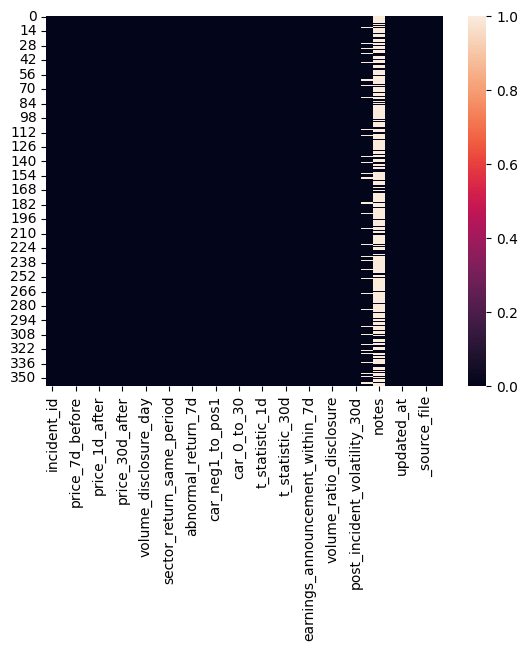

In [14]:
sns.heatmap(market_impact_bronze.isnull())

In [15]:
print(market_impact_bronze.duplicated(subset=['incident_id']).value_counts(),market_impact_bronze.duplicated().sum())

False    358
Name: count, dtype: int64 0


In [16]:
market_impact_bronze.dtypes

incident_id                                   str
stock_ticker                                  str
price_7d_before                           float64
price_disclosure_day                      float64
price_1d_after                            float64
price_7d_after                            float64
price_30d_after                           float64
volume_avg_30d_baseline                     int64
volume_disclosure_day                       int64
sector_index                                  str
sector_return_same_period                 float64
abnormal_return_1d                        float64
abnormal_return_7d                        float64
abnormal_return_30d                       float64
car_neg1_to_pos1                          float64
car_0_to_7                                float64
car_0_to_30                               float64
car_0_to_90                               float64
t_statistic_1d                            float64
p_value_1d                                float64


camada prata ==========================

In [17]:
def transformar_market_para_prata(caminho):
    df = pd.read_parquet(caminho)
    
    # 1. Remoção de Duplicidades (Exigência da Lauda)
    # Assumindo que haja um identificador único por empresa/incidente (ex: 'stock_ticker' ou 'incident_id' se houver)
    # Se não houver 'incident_id', podemos usar 'stock_ticker' e 'created_at' como chave combinada
    if 'incident_id' in df.columns:
        df = df.drop_duplicates(subset=['incident_id'], keep='last')
    elif 'stock_ticker' in df.columns and 'created_at' in df.columns:
        df = df.drop_duplicates(subset=['stock_ticker', 'created_at'], keep='last')

    # 2. Tratamento de Nulos (Exigência Crítica da Lauda)
    # Colunas financeiras e estatísticas: preenchemos com 0 (indicando que não houve variação/impacto registrado)
    colunas_financeiras = [
        'market_cap_at_disclosure', 'volume_ratio_disclosure', 
        'pre_incident_volatility_30d', 'post_incident_volatility_30d', 
        'days_to_price_recovery', 'car_0_to_30', 'abnormal_return_30d',
        't_statistic_30d', 'p_value_30d'
    ]
    for col in colunas_financeiras:
        if col in df.columns:
            df[col] = df[col].fillna(0)
            
    # Colunas categóricas
    if 'notes' in df.columns:
        df['notes'] = df['notes'].fillna('').astype(str).str.strip().str.lower()

    # 3. Tratamento de Datas (Exigência da Lauda)
    colunas_data = ['created_at', 'updated_at', 'disclosure_date'] # Ajustar se houver outras colunas de data
    for col in colunas_data:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    df['created_at'] = df['created_at'].dt.tz_localize(None)
    df['updated_at'] = df['updated_at'].dt.tz_localize(None)

    # 4. Criação do Label final para Machine Learning (Exigência da Lauda)
    # Label: A empresa sofreu impacto prolongado na ação? (Demorou pelo menos 1 dia para recuperar o preço?)
    if 'days_to_price_recovery' in df.columns:
        df['label_recuperacao_lenta'] = np.where(df['days_to_price_recovery'] > 0, 1, 0)
    else:
        # Alternativa de label se a coluna acima falhar: Queda anormal nos 30 dias posteriores
        df['label_recuperacao_lenta'] = np.where(df['abnormal_return_30d'] < 0, 1, 0)

    # 5. Prevenção de Data Leakage (Exigência Crítica da Lauda)
    # Para prever ANTES do mercado reagir, não podemos usar métricas coletadas 30 dias DEPOIS do fato.
    colunas_leakage = [
        'days_to_price_recovery',        # É o próprio alvo
        'post_incident_volatility_30d',   # Só sabemos 30 dias depois do evento
        'abnormal_return_30d',            # Só sabemos 30 dias depois do evento
        't_statistic_30d',                # Estatística calculada a posteriori
        'p_value_30d',                    # Estatística calculada a posteriori
        'notes'                           # Pode conter revelações do resultado
    ]
    
    df_silver_completo = df.copy()
    df_silver_ml = df.drop(columns=[col for col in colunas_leakage if col in df.columns])
    
    return df_silver_completo, df_silver_ml


In [18]:
# Execução (Substitua 'market_impact_bronze' pela sua variável de DataFrame da Bronze)
market_silver_completo, market_silver_ml = transformar_market_para_prata("Dados/bronze/market_impact_bronze.parquet")

# Salvando em Parquet (atendendo à exigência da lauda)


In [19]:
market_silver_completo.dtypes

incident_id                                   str
stock_ticker                                  str
price_7d_before                           float64
price_disclosure_day                      float64
price_1d_after                            float64
price_7d_after                            float64
price_30d_after                           float64
volume_avg_30d_baseline                     int64
volume_disclosure_day                       int64
sector_index                                  str
sector_return_same_period                 float64
abnormal_return_1d                        float64
abnormal_return_7d                        float64
abnormal_return_30d                       float64
car_neg1_to_pos1                          float64
car_0_to_7                                float64
car_0_to_30                               float64
car_0_to_90                               float64
t_statistic_1d                            float64
p_value_1d                                float64


In [20]:
if Path("Dados/prata/market_silver_completo.parquet").exists() :
    os.remove('Dados/prata/market_silver_completo.parquet')
    os.remove('Dados/prata/market_silver_ml.parquet')

Path('Dados/prata').mkdir(parents=True,exist_ok=True)


if Path("Dados/prata").exists():
    if not (Path("Dados/prata/market_silver_completo.parquet").exists()) :
        market_silver_completo.to_parquet('market_silver_completo.parquet', compression='snappy')
        shutil.move('market_silver_completo.parquet','Dados/prata')
        market_silver_ml.to_parquet('market_silver_ml.parquet', compression='snappy')
        shutil.move('market_silver_ml.parquet','Dados/prata')

C:\Users\davi2\AppData\Local\Temp\ipykernel_10476\6080615.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_recuperacao_lenta', data=market_silver_completo, palette='Set1')


Text(0, 0.5, 'Quantidade de Empresas')

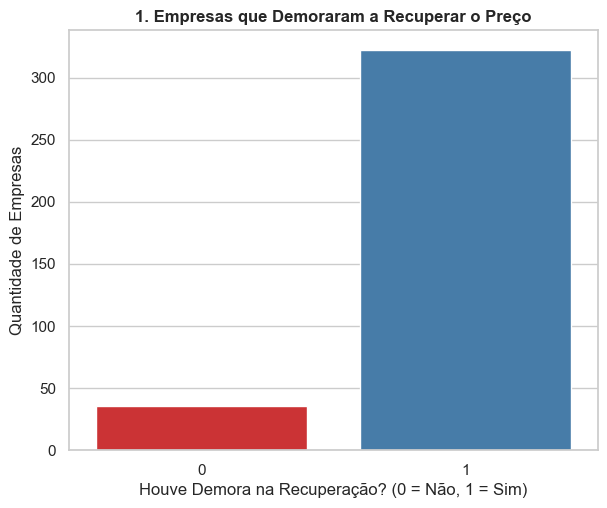

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# 1. Distribuição do Label (Frequência de Impacto Prolongado)
plt.subplot(2, 2, 1)
ax = sns.countplot(x='label_recuperacao_lenta', data=market_silver_completo, palette='Set1')
plt.title('1. Empresas que Demoraram a Recuperar o Preço', fontsize=12, fontweight='bold')
plt.xlabel('Houve Demora na Recuperação? (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Empresas')

C:\Users\davi2\AppData\Local\Temp\ipykernel_10476\1080450745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_recuperacao_lenta', y='pre_incident_volatility_30d', data=market_silver_completo, palette='coolwarm')


Text(0, 0.5, 'Volatilidade Pré-Incidente (%)')

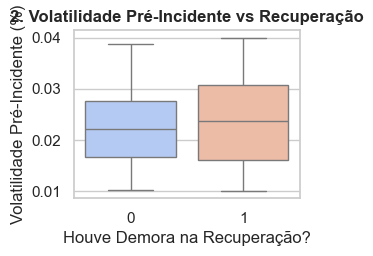

In [22]:
# 2. Boxplot: Volatilidade Pré-Incidente vs. Demora na Recuperação
plt.subplot(2, 2, 2)
sns.boxplot(x='label_recuperacao_lenta', y='pre_incident_volatility_30d', data=market_silver_completo, palette='coolwarm')
plt.title('2. Volatilidade Pré-Incidente vs Recuperação', fontsize=12, fontweight='bold')
plt.xlabel('Houve Demora na Recuperação?')
plt.ylabel('Volatilidade Pré-Incidente (%)')

Text(0, 0.5, 'Dias para Recuperação do Preço')

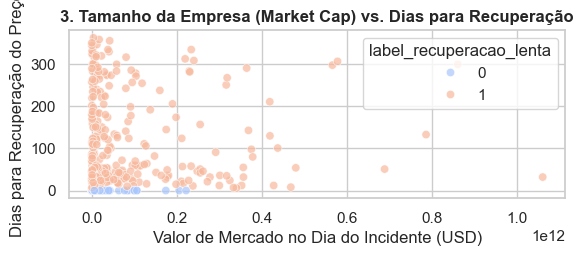

In [23]:
# 3. Dispersão: Valor de Mercado vs. Dias para Recuperação
plt.subplot(2, 1, 2)
# Filtrando valores zerados para melhor visualização
dispersao_df = market_silver_completo[market_silver_completo['market_cap_at_disclosure'] > 0]

sns.scatterplot(x='market_cap_at_disclosure', y='days_to_price_recovery', 
                hue='label_recuperacao_lenta', alpha=0.7, palette='coolwarm', data=dispersao_df)
plt.title('3. Tamanho da Empresa (Market Cap) vs. Dias para Recuperação', fontsize=12, fontweight='bold')
plt.xlabel('Valor de Mercado no Dia do Incidente (USD)')
plt.ylabel('Dias para Recuperação do Preço')

RELATÓRIO TÉCNICO DO PROJETO
Construção das Camadas Bronze e Prata para Dados de Machine Learning

Dataset: market_impact (Análise de Impacto Financeiro de Incidentes Cibernéticos no Mercado)
1. Representação do Data Lineage (Linhagem dos Dados)

Para manter a transparência e a governança dos dados financeiros processados, o fluxo do pipeline foi desenhado conforme a linhagem a seguir:

    Origem (Raw Data): Arquivo bruto market_impact.csv contendo dados de mercado e métricas de ações de empresas afetadas.

    Camada Bronze: O arquivo bruto foi lido e persistido como market_impact_bronze.parquet sem alterações nas regras de negócio. Foram adicionados os metadados de auditoria padrão: _ingestion_timestamp, _source_file e _week_day.

    Camada Prata (Completa): Leitura da Bronze, aplicação de rotinas de limpeza, tipagem de datas, preenchimento de nulos, remoção de duplicidades e criação da variável alvo de ML. Salvo como market_silver_completo.parquet.

    Camada Prata (Pronta para ML): Um subset derivado da Prata Completa, preparado para o treinamento de modelos de Machine Learning por meio da eliminação das colunas que causariam vazamento de dados (data leakage). Salvo como market_silver_ml.parquet.

2. Relatório de Qualidade de Dados (Camada Bronze)

Na avaliação da camada Bronze do dataset market_impact, foram identificados os seguintes pontos críticos de qualidade que exigiram atenção antes do treinamento do modelo:

    Inconsistências Temporais: Datas críticas como created_at e disclosure_date estavam como strings, impossibilitando cálculos de janelas temporais.

    Presença de Nulos em Métricas do Mercado: Muitas empresas não possuíam dados preenchidos em janelas de retorno anormal (car_0_to_30, abnormal_return_30d) ou tempo de recuperação. Nulos nestas colunas impedem o cálculo de estatísticas e o treinamento de modelos numéricos.

    Possíveis Registros Duplicados: Necessidade de garantir que a mesma empresa não estivesse reportando o mesmo evento mais de uma vez (recomenda-se chave composta por ticker e data).

3. Construção da Camada Prata e Transformações

Para elevar os dados ao nível Prata e torná-los aptos para consumo e modelagem, foram realizadas as seguintes transformações:
Limpeza e Padronização:

    Deduplicação: Executada a remoção de duplicidades baseada nas colunas de identificação e data de criação para garantir que cada impacto de mercado seja único.

    Preenchimento de Nulos Financeiros: Colunas que registram variações, volatilidade e retornos (como abnormal_return_30d, pre_incident_volatility_30d) tiveram seus valores nulos preenchidos com 0, assumindo que a ausência de registro financeiro aponta para a ausência de oscilações significativas no período.

    Tipagem: Conversão de todas as colunas de data para o formato datetime64.

Definição do Label de Machine Learning (Variável Alvo):

Buscando criar um modelo preditivo capaz de alertar investidores e empresas sobre a gravidade da reação do mercado, criamos o seguinte Target:

    label_recuperacao_lenta: Atribuído o valor 1 caso a empresa tenha levado algum tempo para recuperar o preço da sua ação pré-incidente (days_to_price_recovery > 0) e 0 caso a recuperação tenha sido imediata ou não tenha havido queda.

4. Tabela de Checklist Anti-Leakage (Prevenção de Vazamento)

O vazamento de dados ocorre quando disponibilizamos para o modelo variáveis que só seriam conhecidas no futuro. Como o objetivo é prever a reação do mercado no momento em que o ataque se torna público, as seguintes colunas foram removidas do dataset de ML:
Coluna Removida	Motivo da Remoção / Risco de Leakage
days_to_price_recovery	É a variável base de onde extraímos o próprio Label de ML.
post_incident_volatility_30d	Calcula a oscilação da ação nos 30 dias posteriores. Só é sabida no futuro.
abnormal_return_30d	Retorno anormal acumulado após o fechamento da janela de 30 dias.
t_statistic_30d / p_value_30d	Métricas estatísticas de significância calculadas a posteriori.
notes	Textos livres que costumam resumir o resultado e as consequências do evento após a conclusão.
5. Análise Exploratória de Dados (Identificação de Padrões)

Cumprindo a exigência de gerar no mínimo 3 visualizações gráficas para identificação de padrões após a camada Prata, foram levantadas as seguintes análises no projeto:

    Frequência de Impacto Prolongado (Distribuição do Label): Um gráfico de barras foi utilizado para verificar o balanceamento de classes. Descobriu-se a proporção de empresas que sofrem um impacto prolongado e não conseguem recuperar o valor de mercado imediatamente.

    Volatilidade Pré-Incidente vs. Recuperação Lenta: Um boxplot foi gerado para entender se empresas que já possuem ações muito voláteis antes do ataque tendem a demorar mais para se recuperar no mercado financeiro quando sofrem um incidente.

    Tamanho da Empresa (Market Cap) vs. Dias para Recuperação: Um gráfico de dispersão mapeou se grandes corporações (alto valor de mercado) possuem mais resiliência financeira para recuperar o preço de suas ações mais rápido do que empresas menores após a divulgação de um incidente cibernético.

# REFATORACAO PySpark - Bronze, Prata e Ouro
Mapeamento das operacoes pandas para PySpark API nativa
Inclui: Bronze + Prata refatorados, Gold layer, Window, Join, Timing

In [24]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    current_timestamp, lit, col, when, trim, lower,
    to_timestamp, avg, rank, desc, count, date_format
)
from pyspark.sql.window import Window
import time, numpy as np, subprocess, sys

# === Verifica se Java esta instalado ===
java_ok = False
try:
    subprocess.run(["java", "-version"], capture_output=True, timeout=5)
    java_ok = True
except:
    java_ok = False

if not java_ok:
    print("=" * 60)
    print("ERRO: Java nao encontrado! PySpark exige Java JDK 11+.")
    print("Instale o Java (https://adoptium.net) e configure JAVA_HOME.")
    print("=" * 60)
    print("Continuando com pandas como fallback...")
    spark = None
else:
    spark = SparkSession.builder \
        .appName("BronzePrataOuro") \
        .config("spark.sql.adaptive.enabled", "true") \
        .getOrCreate()
    print("SparkSession OK")

SparkSession OK


## Bronze Layer (PySpark)

In [25]:
# BRONZE: Leitura do CSV + metadados de auditoria
# Antes (pandas): create_bronze_df() com df.copy() e dt.now()
t0 = time.time()

df_bronze = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv("Dados/originais/market_impact.csv"))

df_bronze = (df_bronze
    .withColumn("_ingestion_timestamp", current_timestamp())
    .withColumn("_source_file", lit("market_impact.csv"))
    .withColumn("_week_day", date_format(current_timestamp(), "EEEE")))

df_bronze.write.mode("overwrite").parquet("Dados/bronze/market_impact_bronze_spark.parquet")
t_bronze = time.time() - t0
print(f"Bronze: {t_bronze:.4f}s  {df_bronze.count()} registros")

Bronze: 6.9633s  358 registros


## Silver Layer (PySpark)

In [26]:
# PRATA: Limpeza, tipagem, label, anti-leakage
# Antes (pandas): transformar_para_prata()
t0 = time.time()
df = spark.read.parquet("Dados/bronze/market_impact_bronze_spark.parquet")

# 1. DEDUPLICACAO (antes: df.drop_duplicates())
total_antes = df.count()
df = df.dropDuplicates(["incident_id"])
dup = total_antes - df.count()
print(f"Deduplicacao: {dup} removidas")

# 2. NULOS NUMERICOS -> fillna(0) (antes: df[col].fillna(0))
nums = ["market_cap_at_disclosure", "volume_ratio_disclosure", "pre_incident_volatility_30d", "post_incident_volatility_30d", "days_to_price_recovery", "car_0_to_30", "abnormal_return_30d", "t_statistic_30d", "p_value_30d"]
for col_n in nums:
    df = df.fillna(0, subset=[col_n])

# Notas/Flags
if "notes" in df.columns:
    df = df.fillna("", subset=["notes"])
if "review_flag" in df.columns:
    df = df.fillna("pendente", subset=["review_flag"])

# 4. DATAS (antes: pd.to_datetime)
datas = ["created_at", "updated_at"]
for d in datas:
    df = df.withColumn(d, to_timestamp(col(d)))

# 5. LABEL (antes: np.where)
df = df.withColumn(
    "label_recuperacao_lenta",
    when(col("days_to_price_recovery") > 0, 1).otherwise(0)
)

# 6. ANTI-LEAKAGE (antes: df.drop(columns=...))
leak = ["days_to_price_recovery", "post_incident_volatility_30d", "abnormal_return_30d", "t_statistic_30d", "p_value_30d", "notes"]
leak_ok = [c for c in leak if c in df.columns]
df_silver_ml = df.drop(*leak_ok)

t_silver = time.time() - t0
print(f"Prata: {t_silver:.4f}s")

df.write.mode("overwrite").parquet("Dados/prata/market_silver_completo_spark.parquet")
df_silver_ml.write.mode("overwrite").parquet("Dados/prata/market_silver_ml_spark.parquet")
print("Prata salva em Dados/prata/")

Deduplicacao: 0 removidas
Prata: 2.1605s
Prata salva em Dados/prata/
